# 📓 Olist – Data Warehouse Cleaning Pipeline
---

**Obiettivo:** Pipeline di pulizia modulare e auditabile per le 9 tabelle Olist destinate al DW.  
Ogni trasformazione è loggata, tracciabile e reversibile.

| Step | Tecnica | Concern DW |
|------|---------|------------|
| **0. Setup** | Path locali, import, configurazione | Riproducibilità |
| **1. Caricamento** | Lettura CSV con dtype control | Schema enforcement |
| **2. Deduplicazione** | Exact match per tabella | Integrità surrogate key |
| **3. Standardizzazione** | Casing, whitespace, categorie | Conforming dimensions |
| **4. Parsing date** | Normalizzazione timestamp | Slowly Changing Dimensions |
| **5. Imputazione** | Mediana, forward-fill, flag | Strategia MCAR/MAR |
| **6. Outlier** | Rilevamento IQR + flag | Affidabilità aggregati |
| **7. Arricchimento** | Join categoria EN, colonne derivate | Conforming Dimensions |
| **8. Audit Log** | Before/after per ogni step | Lineage & compliance |
| **9. Export** | CSV puliti in output folder | Staging area DW |

**Tabelle sorgente:**
- `olist_customers_dataset.csv` → dimensione clienti
- `olist_sellers_dataset.csv` → dimensione venditori
- `olist_products_dataset.csv` → dimensione prodotti
- `olist_orders_dataset.csv` → fatto ordini
- `olist_order_items_dataset.csv` → fatto righe ordine
- `olist_order_payments_dataset.csv` → fatto pagamenti
- `olist_order_reviews_dataset.csv` → fatto recensioni
- `olist_geolocation_dataset.csv` → dimensione geolocalizzazione
- `product_category_name_translation.csv` → lookup categorie

## ⚙️ 0. Setup – Path locali, Import, Configurazione

In [ ]:
# python -m pip install recordlinkage scikit-learn scipy --quiet

In [1]:
import pandas as pd
import numpy as np
import re
import warnings
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import datetime
from copy import deepcopy
from sklearn.impute import KNNImputer
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
np.random.seed(42)

print('✅ Librerie caricate')

✅ Librerie caricate


In [2]:
# ─── Configura i path locali ────────────────────────────────────────────────
# I path sono calcolati automaticamente relativi alla cartella consegna/

_HERE = os.path.dirname(os.path.abspath("__file__"))  # consegna/2_scripts/
_ROOT = os.path.dirname(_HERE)                         # consegna/

INPUT_PATH  = os.path.join(_ROOT, "1_raw_data")  + os.sep   # consegna/1_raw_data/
OUTPUT_PATH = os.path.join(_ROOT, "3_cleaned_data") + os.sep # consegna/3_cleaned_data/

os.makedirs(OUTPUT_PATH, exist_ok=True)
print(f'📂 Input:  {os.path.abspath(INPUT_PATH)}')
print(f'📂 Output: {os.path.abspath(OUTPUT_PATH)}')

📂 Input:  ...consegna/1_raw_data
📂 Output: ...consegna/3_cleaned_data


## 📊 1. Caricamento – Lettura controllata dei CSV

In [3]:
# ─── Audit log globale ──────────────────────────────────────────────────────
# Ogni step registra: tabella, step, n_righe_prima, n_righe_dopo, n_modifiche, note

audit_log = []

def log_step(table, step, before_shape, after_shape, changes=None, notes=''):
    """Registra nel log globale ogni trasformazione applicata."""
    entry = {
        'timestamp'    : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'table'        : table,
        'step'         : step,
        'rows_before'  : before_shape[0],
        'cols_before'  : before_shape[1],
        'rows_after'   : after_shape[0],
        'cols_after'   : after_shape[1],
        'rows_changed' : changes if changes is not None else (before_shape[0] - after_shape[0]),
        'notes'        : notes
    }
    audit_log.append(entry)
    print(f"  [{step}] {table}: {before_shape[0]:,} → {after_shape[0]:,} righe | {notes}")

print('✅ Audit log inizializzato')

✅ Audit log inizializzato


In [4]:
# ─── Caricamento di tutte le tabelle ────────────────────────────────────────

print('⏳ Caricamento CSV...')

customers    = pd.read_csv(INPUT_PATH + 'olist_customers_dataset.csv')
sellers      = pd.read_csv(INPUT_PATH + 'olist_sellers_dataset.csv')
products     = pd.read_csv(INPUT_PATH + 'olist_products_dataset.csv')
orders       = pd.read_csv(INPUT_PATH + 'olist_orders_dataset.csv')
order_items  = pd.read_csv(INPUT_PATH + 'olist_order_items_dataset.csv')
payments     = pd.read_csv(INPUT_PATH + 'olist_order_payments_dataset.csv')
reviews      = pd.read_csv(INPUT_PATH + 'olist_order_reviews_dataset.csv')
geolocation  = pd.read_csv(INPUT_PATH + 'olist_geolocation_dataset.csv')
cat_transl   = pd.read_csv(INPUT_PATH + 'product_category_name_translation.csv')

# Dizionario per iterare facilmente
tables = {
    'customers'   : customers,
    'sellers'     : sellers,
    'products'    : products,
    'orders'      : orders,
    'order_items' : order_items,
    'payments'    : payments,
    'reviews'     : reviews,
    'geolocation' : geolocation,
    'cat_transl'  : cat_transl,
}

print('\n📋 Riepilogo tabelle caricate:')
for name, df in tables.items():
    miss = df.isnull().sum().sum()
    dups = df.duplicated().sum()
    print(f'  {name:<16} {df.shape[0]:>8,} righe × {df.shape[1]:>2} col '
          f'| missing: {miss:>5,} | duplicati: {dups:>6,}')

⏳ Caricamento CSV...

📋 Riepilogo tabelle caricate:
  customers          99,441 righe ×  5 col | missing:     0 | duplicati:      0
  sellers             3,095 righe ×  4 col | missing:     0 | duplicati:      0
  products           32,951 righe ×  9 col | missing: 2,448 | duplicati:      0
  orders             99,441 righe ×  8 col | missing: 4,908 | duplicati:      0
  order_items       112,650 righe ×  7 col | missing:     0 | duplicati:      0
  payments          103,886 righe ×  5 col | missing:     0 | duplicati:      0
  reviews            99,224 righe ×  7 col | missing: 145,903 | duplicati:      0
  geolocation      1,000,163 righe ×  5 col | missing:     0 | duplicati: 261,831
  cat_transl             71 righe ×  2 col | missing:     0 | duplicati:      0


## 🔍 2. Deduplicazione – Rimozione righe duplicate

In [5]:
# ─── Deduplicazione exact match ─────────────────────────────────────────────
# geolocation ha ~260k duplicati esatti da rimuovere.
# Per le altre tabelle verifichiamo per sicurezza.

print('🔧 STEP 2 – Deduplicazione\n')

# Chiavi primarie attese per ogni tabella (per dedup semantica)
pk_map = {
    'customers'   : ['customer_id'],
    'sellers'     : ['seller_id'],
    'products'    : ['product_id'],
    'orders'      : ['order_id'],
    'order_items' : ['order_id', 'order_item_id'],
    'payments'    : ['order_id', 'payment_sequential'],
    'reviews'     : ['review_id'],
    'geolocation' : ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng'],
    'cat_transl'  : ['product_category_name'],
}

for name, df in tables.items():
    before = df.shape
    pk = pk_map[name]
    
    # Dedup esatto su tutte le colonne
    df_clean = df.drop_duplicates()
    
    # Dedup semantica sulla chiave primaria (mantieni prima occorrenza)
    df_clean = df_clean.drop_duplicates(subset=pk, keep='first')
    
    tables[name] = df_clean
    log_step(name, 'deduplication', before, df_clean.shape,
             notes=f'PK={pk}, rimossi {before[0]-df_clean.shape[0]:,} duplicati')

# Aggiorna variabili singole
customers, sellers, products = tables['customers'], tables['sellers'], tables['products']
orders, order_items = tables['orders'], tables['order_items']
payments, reviews, geolocation = tables['payments'], tables['reviews'], tables['geolocation']
cat_transl = tables['cat_transl']

🔧 STEP 2 – Deduplicazione

  [deduplication] customers: 99,441 → 99,441 righe | PK=['customer_id'], rimossi 0 duplicati
  [deduplication] sellers: 3,095 → 3,095 righe | PK=['seller_id'], rimossi 0 duplicati
  [deduplication] products: 32,951 → 32,951 righe | PK=['product_id'], rimossi 0 duplicati
  [deduplication] orders: 99,441 → 99,441 righe | PK=['order_id'], rimossi 0 duplicati
  [deduplication] order_items: 112,650 → 112,650 righe | PK=['order_id', 'order_item_id'], rimossi 0 duplicati
  [deduplication] payments: 103,886 → 103,886 righe | PK=['order_id', 'payment_sequential'], rimossi 0 duplicati
  [deduplication] reviews: 99,224 → 98,410 righe | PK=['review_id'], rimossi 814 duplicati
  [deduplication] geolocation: 1,000,163 → 720,154 righe | PK=['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng'], rimossi 280,009 duplicati
  [deduplication] cat_transl: 71 → 71 righe | PK=['product_category_name'], rimossi 0 duplicati


## 🧹 3. Standardizzazione – Casing, Whitespace, Valori canonici

In [6]:
# ─── 3a. Customers: city e state ────────────────────────────────────────────
print('🔧 STEP 3 – Standardizzazione\n')

before = customers.shape
customers['customer_city']  = customers['customer_city'].str.strip().str.title()
customers['customer_state'] = customers['customer_state'].str.strip().str.upper()
log_step('customers', 'standardization', before, customers.shape,
         changes=0, notes='city→title, state→upper, strip whitespace')

🔧 STEP 3 – Standardizzazione

  [standardization] customers: 99,441 → 99,441 righe | city→title, state→upper, strip whitespace


In [7]:
# ─── 3b. Sellers: city e state ──────────────────────────────────────────────
before = sellers.shape
sellers['seller_city']  = sellers['seller_city'].str.strip().str.title()
sellers['seller_state'] = sellers['seller_state'].str.strip().str.upper()
log_step('sellers', 'standardization', before, sellers.shape,
         changes=0, notes='city→title, state→upper, strip whitespace')

  [standardization] sellers: 3,095 → 3,095 righe | city→title, state→upper, strip whitespace


In [8]:
# ─── 3c. Products: category name – strip e lower ────────────────────────────
before = products.shape
products['product_category_name'] = (
    products['product_category_name']
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', '_', regex=True)  # normalizza spazi interni
)
log_step('products', 'standardization', before, products.shape,
         changes=0, notes='category_name: strip, lower, spazi→underscore')

  [standardization] products: 32,951 → 32,951 righe | category_name: strip, lower, spazi→underscore


In [9]:
# ─── 3d. Orders: order_status canonicalizzazione ────────────────────────────
before = orders.shape
print('  Valori unici order_status prima:', orders['order_status'].unique())
orders['order_status'] = orders['order_status'].str.strip().str.lower()
print('  Valori unici order_status dopo: ', orders['order_status'].unique())
log_step('orders', 'standardization', before, orders.shape,
         changes=0, notes='order_status: strip + lower')

  Valori unici order_status prima: ['delivered' 'invoiced' 'shipped' 'processing' 'unavailable' 'canceled'
 'created' 'approved']
  Valori unici order_status dopo:  ['delivered' 'invoiced' 'shipped' 'processing' 'unavailable' 'canceled'
 'created' 'approved']
  [standardization] orders: 99,441 → 99,441 righe | order_status: strip + lower


In [10]:
# ─── 3e. Payments: payment_type canonicalizzazione ──────────────────────────
before = payments.shape
payments['payment_type'] = payments['payment_type'].str.strip().str.lower()
print('  Valori unici payment_type:', payments['payment_type'].unique())
log_step('payments', 'standardization', before, payments.shape,
         changes=0, notes='payment_type: strip + lower')

  Valori unici payment_type: ['credit_card' 'boleto' 'voucher' 'debit_card' 'not_defined']
  [standardization] payments: 103,886 → 103,886 righe | payment_type: strip + lower


In [11]:
# ─── 3f. Geolocation: city e state ──────────────────────────────────────────
before = geolocation.shape
geolocation['geolocation_city']  = geolocation['geolocation_city'].str.strip().str.title()
geolocation['geolocation_state'] = geolocation['geolocation_state'].str.strip().str.upper()
log_step('geolocation', 'standardization', before, geolocation.shape,
         changes=0, notes='city→title, state→upper')

  [standardization] geolocation: 720,154 → 720,154 righe | city→title, state→upper


In [12]:
# ─── 3g. Geolocation: filtro coordinate fuori range + aggregazione per ZIP ───
print('\n🔧 STEP 3g – Geolocation aggregazione per ZIP\n')
before = geolocation.shape

# Filtra coordinate fuori dal range geografico del Brasile
geolocation = geolocation[
    (geolocation['geolocation_lat'].between(-33.75, 5.27)) &
    (geolocation['geolocation_lng'].between(-73.99, -34.79))
].copy()
n_filtered = before[0] - len(geolocation)
print(f'  Coordinate fuori range rimosse: {n_filtered:,}')

# Aggrega per ZIP: centroide lat/lng + moda city/state
geolocation = geolocation.groupby('geolocation_zip_code_prefix').agg(
    geolocation_lat   = ('geolocation_lat',  'mean'),
    geolocation_lng   = ('geolocation_lng',  'mean'),
    geolocation_city  = ('geolocation_city',  lambda x: x.mode().iloc[0]),
    geolocation_state = ('geolocation_state', lambda x: x.mode().iloc[0]),
    n_records         = ('geolocation_lat',  'count')
).reset_index()

log_step('geolocation', 'geo_aggregation_per_zip', before, geolocation.shape,
         changes=before[0]-geolocation.shape[0],
         notes=f'Filtro coords fuori Brasile + aggregazione per ZIP → centroide lat/lng, moda city/state')
print(f'  Risultato: {len(geolocation):,} record (1 per ZIP)')


🔧 STEP 3g – Geolocation aggregazione per ZIP

  Coordinate fuori range rimosse: 33
  [geo_aggregation_per_zip] geolocation: 720,154 → 19,010 righe | Filtro coords fuori Brasile + aggregazione per ZIP → centroide lat/lng, moda city/state
  Risultato: 19,010 record (1 per ZIP)


## 📅 4. Parsing Date – Normalizzazione timestamp

In [13]:
# ─── Colonne data in orders ──────────────────────────────────────────────────
print('🔧 STEP 4 – Parsing date\n')

date_cols_orders = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

before = orders.shape
for col in date_cols_orders:
    orders[col] = pd.to_datetime(orders[col], errors='coerce', utc=False)

log_step('orders', 'date_parsing', before, orders.shape,
         changes=0, notes=f'Convertite {len(date_cols_orders)} colonne datetime')

print('  Esempio orders dopo parsing:')
print(orders[date_cols_orders].dtypes)

🔧 STEP 4 – Parsing date

  [date_parsing] orders: 99,441 → 99,441 righe | Convertite 5 colonne datetime
  Esempio orders dopo parsing:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [14]:
# ─── Colonne data in order_items ─────────────────────────────────────────────
before = order_items.shape
order_items['shipping_limit_date'] = pd.to_datetime(
    order_items['shipping_limit_date'], errors='coerce'
)
log_step('order_items', 'date_parsing', before, order_items.shape,
         changes=0, notes='shipping_limit_date → datetime')

  [date_parsing] order_items: 112,650 → 112,650 righe | shipping_limit_date → datetime


In [15]:
# ─── Colonne data in reviews ─────────────────────────────────────────────────
before = reviews.shape
reviews['review_creation_date']   = pd.to_datetime(reviews['review_creation_date'],   errors='coerce')
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'], errors='coerce')
log_step('reviews', 'date_parsing', before, reviews.shape,
         changes=0, notes='2 colonne datetime convertite')

  [date_parsing] reviews: 98,410 → 98,410 righe | 2 colonne datetime convertite


## 🩹 5. Imputazione – Gestione valori mancanti

In [16]:
# ─── Report missing values PRIMA dell'imputazione ───────────────────────────
print('🔧 STEP 5 – Imputazione valori mancanti\n')
print('📋 Missing values per tabella (prima):')
for name, df in tables.items():
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    if len(miss):
        print(f'  {name}:')
        for col, n in miss.items():
            print(f'    {col}: {n:,} ({n/len(df)*100:.1f}%)')

🔧 STEP 5 – Imputazione valori mancanti

📋 Missing values per tabella (prima):
  products:
    product_category_name: 610 (1.9%)
    product_name_lenght: 610 (1.9%)
    product_description_lenght: 610 (1.9%)
    product_photos_qty: 610 (1.9%)
    product_weight_g: 2 (0.0%)
    product_length_cm: 2 (0.0%)
    product_height_cm: 2 (0.0%)
    product_width_cm: 2 (0.0%)
  orders:
    order_approved_at: 160 (0.2%)
    order_delivered_carrier_date: 1,783 (1.8%)
    order_delivered_customer_date: 2,965 (3.0%)
  reviews:
    review_comment_title: 86,891 (88.3%)
    review_comment_message: 57,742 (58.7%)


In [17]:
# ─── 5a. Products: valori mancanti ──────────────────────────────────────────
# product_category_name: ~610 mancanti → imputa con 'unknown'
# dimensioni fisiche: 2 mancanti → mediana

before = products.shape
missing_before = products.isnull().sum().sum()

# Categoria mancante → 'unknown' (MCAR, non imputabile con logica)
products['product_category_name'] = products['product_category_name'].fillna('unknown')
products['_category_imputed'] = (products['product_category_name'] == 'unknown').astype(int)

# Dimensioni fisiche: mediana per evitare distorsioni da outlier
dim_cols = ['product_name_lenght', 'product_description_lenght',
            'product_photos_qty', 'product_weight_g',
            'product_length_cm', 'product_height_cm', 'product_width_cm']

for col in dim_cols:
    median_val = products[col].median()
    products[f'_{col}_imputed'] = products[col].isnull().astype(int)
    products[col] = products[col].fillna(median_val)

missing_after = products.isnull().sum().sum()
log_step('products', 'imputation', before, products.shape,
         changes=missing_before - missing_after,
         notes='category→unknown, dimensioni→mediana, flag _imputed aggiunti')

  [imputation] products: 32,951 → 32,951 righe | category→unknown, dimensioni→mediana, flag _imputed aggiunti


In [18]:
# ─── 5b. Orders: date di consegna mancanti ──────────────────────────────────
# order_approved_at: 160 mancanti → ordini non approvati (flag)
# order_delivered_*: mancanti perché ordine in transito → flag binario

before = orders.shape

# Flag: 1 = valore mancante (semanticamente rilevante per DW)
orders['_approved_missing']          = orders['order_approved_at'].isnull().astype(int)
orders['_delivered_carrier_missing'] = orders['order_delivered_carrier_date'].isnull().astype(int)
orders['_delivered_customer_missing']= orders['order_delivered_customer_date'].isnull().astype(int)

# Non imputiamo le date: il mancato valore è informazione (ordine non consegnato)

log_step('orders', 'imputation', before, orders.shape,
         changes=0, notes='Date mancanti → flag binari (mancanza = informazione)')

  [imputation] orders: 99,441 → 99,441 righe | Date mancanti → flag binari (mancanza = informazione)


In [19]:
# ─── 5b-bis. Orders: feature engineering ─────────────────────────────────────
print('\n🔧 STEP 5b-bis – Orders: feature engineering\n')
before = orders.shape

# Giorni tra acquisto e consegna effettiva
orders['delivery_lead_days'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.days

# Ritardo rispetto alla data stimata (negativo = anticipo)
orders['delivery_delay_days'] = (
    orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']
).dt.days

# Attributi temporali per dim_date
orders['purchase_year']  = orders['order_purchase_timestamp'].dt.year
orders['purchase_month'] = orders['order_purchase_timestamp'].dt.month

log_step('orders', 'feature_engineering', before, orders.shape,
         changes=0,
         notes='delivery_lead_days, delivery_delay_days, purchase_year, purchase_month')
print(f'  orders ora ha {orders.shape[1]} colonne')
print(f'  Esempio delivery_lead_days (media consegnati): '
      f'{orders["delivery_lead_days"].mean():.1f} giorni')


🔧 STEP 5b-bis – Orders: feature engineering

  [feature_engineering] orders: 99,441 → 99,441 righe | delivery_lead_days, delivery_delay_days, purchase_year, purchase_month
  orders ora ha 15 colonne
  Esempio delivery_lead_days (media consegnati): 12.1 giorni


In [24]:
# ─── 5a-bis. Products: join cat_transl + IQR su misure fisiche ───────────────
def flag_outliers_iqr(df, col, table_name=''):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    df[f'_{col}_outlier'] = ((df[col] < lower) | (df[col] > upper)).astype(int)
    print(f'  {table_name}.{col}: soglie IQR=[{lower:.2f}, {upper:.2f}] – {n_out:,} outlier trovati (flaggati, NON modificati)')
    return df

print('\n🔧 STEP 5a-bis – Products: categoria EN + outlier fisici\n')
before = products.shape

# Rimuovi colonne esistenti di traduzione EN per evitare conflitti nel merge
products = products.drop(columns=[col for col in products.columns if 'product_category_name_english' in col], errors='ignore')

# Join con traduzione categorie
products = products.merge(cat_transl, on='product_category_name', how='left')
# Riempi EN mancanti (categoria 'unknown' non ha traduzione)
products['product_category_name_english'] = products['product_category_name_english'].fillna('unknown')
print(f'  Colonna EN aggiunta: {products["product_category_name_english"].nunique()} categorie uniche')

# IQR outlier su misure fisiche
phys_cols = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
for col in phys_cols:
    products = flag_outliers_iqr(products, col, table_name='products')

n_out_phys = sum(products[f'_{c}_outlier'].sum() for c in phys_cols)
log_step('products', 'enrich_and_outlier_iqr', before, products.shape,
         changes=n_out_phys,
         notes='Join cat_transl→EN, IQR flagging su 4 misure fisiche')
print(f'  products ora ha {products.shape[1]} colonne')


🔧 STEP 5a-bis – Products: categoria EN + outlier fisici

  Colonna EN aggiunta: 72 categorie uniche
  products.product_weight_g: soglie IQR=[-2100.00, 4300.00] – 4,551 outlier trovati (flaggati, NON modificati)
  products.product_length_cm: soglie IQR=[-12.00, 68.00] – 1,380 outlier trovati (flaggati, NON modificati)
  products.product_height_cm: soglie IQR=[-11.50, 40.50] – 1,892 outlier trovati (flaggati, NON modificati)
  products.product_width_cm: soglie IQR=[-7.50, 52.50] – 912 outlier trovati (flaggati, NON modificati)
  [enrich_and_outlier_iqr] products: 32,951 → 32,951 righe | Join cat_transl→EN, IQR flagging su 4 misure fisiche
  products ora ha 22 colonne


In [25]:
# ─── 5c. Reviews: commenti mancanti ─────────────────────────────────────────
# review_comment_title:   ~88k mancanti (84%) → sostituisci con stringa vuota
# review_comment_message: ~58k mancanti (59%) → sostituisci con stringa vuota

before = reviews.shape
reviews['review_comment_title']   = reviews['review_comment_title'].fillna('')
reviews['review_comment_message'] = reviews['review_comment_message'].fillna('')
log_step('reviews', 'imputation', before, reviews.shape,
         changes=0, notes='Commenti mancanti → stringa vuota (assenza di testo)')

  [imputation] reviews: 98,410 → 98,410 righe | Commenti mancanti → stringa vuota (assenza di testo)


## 📦 6. Rilevamento Outlier – Metodo IQR + Flag

In [26]:
# ─── Funzione IQR: rileva outlier e aggiunge flag binario ────────────────────
def flag_outliers_iqr(df, col, table_name=''):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    df[f'_{col}_outlier'] = ((df[col] < lower) | (df[col] > upper)).astype(int)
    print(f'  {table_name}.{col}: soglie IQR=[{lower:.2f}, {upper:.2f}] – {n_out:,} outlier trovati (flaggati, NON modificati)')
    return df

# ─── Applica flagging outlier a order_items ─────────────────────────────────
before = order_items.shape
order_items = flag_outliers_iqr(order_items, 'price',         table_name='order_items')
order_items = flag_outliers_iqr(order_items, 'freight_value', table_name='order_items')
log_step('order_items', 'outlier_iqr_flag', before, order_items.shape,
         changes=int(order_items['_price_outlier'].sum() + order_items['_freight_value_outlier'].sum()),
         notes='Outlier rilevati con metodo IQR – flaggati, valori originali preservati')

  order_items.price: soglie IQR=[-102.60, 277.40] – 8,427 outlier trovati (flaggati, NON modificati)
  order_items.freight_value: soglie IQR=[0.98, 33.25] – 12,134 outlier trovati (flaggati, NON modificati)
  [outlier_iqr_flag] order_items: 112,650 → 112,650 righe | Outlier rilevati con metodo IQR – flaggati, valori originali preservati


In [27]:
# ─── 6b. Outlier IQR – Payments ──────────────────────────────────────────────
print('\n  --- Payments ---')
before = payments.shape
payments = flag_outliers_iqr(payments, 'payment_value', table_name='payments')
log_step('payments', 'outlier_iqr_flag', before, payments.shape,
         changes=int(payments['_payment_value_outlier'].sum()),
         notes='IQR su payment_value – flaggati, valori preservati')


  --- Payments ---
  payments.payment_value: soglie IQR=[-115.78, 344.41] – 7,981 outlier trovati (flaggati, NON modificati)
  [outlier_iqr_flag] payments: 103,886 → 103,886 righe | IQR su payment_value – flaggati, valori preservati


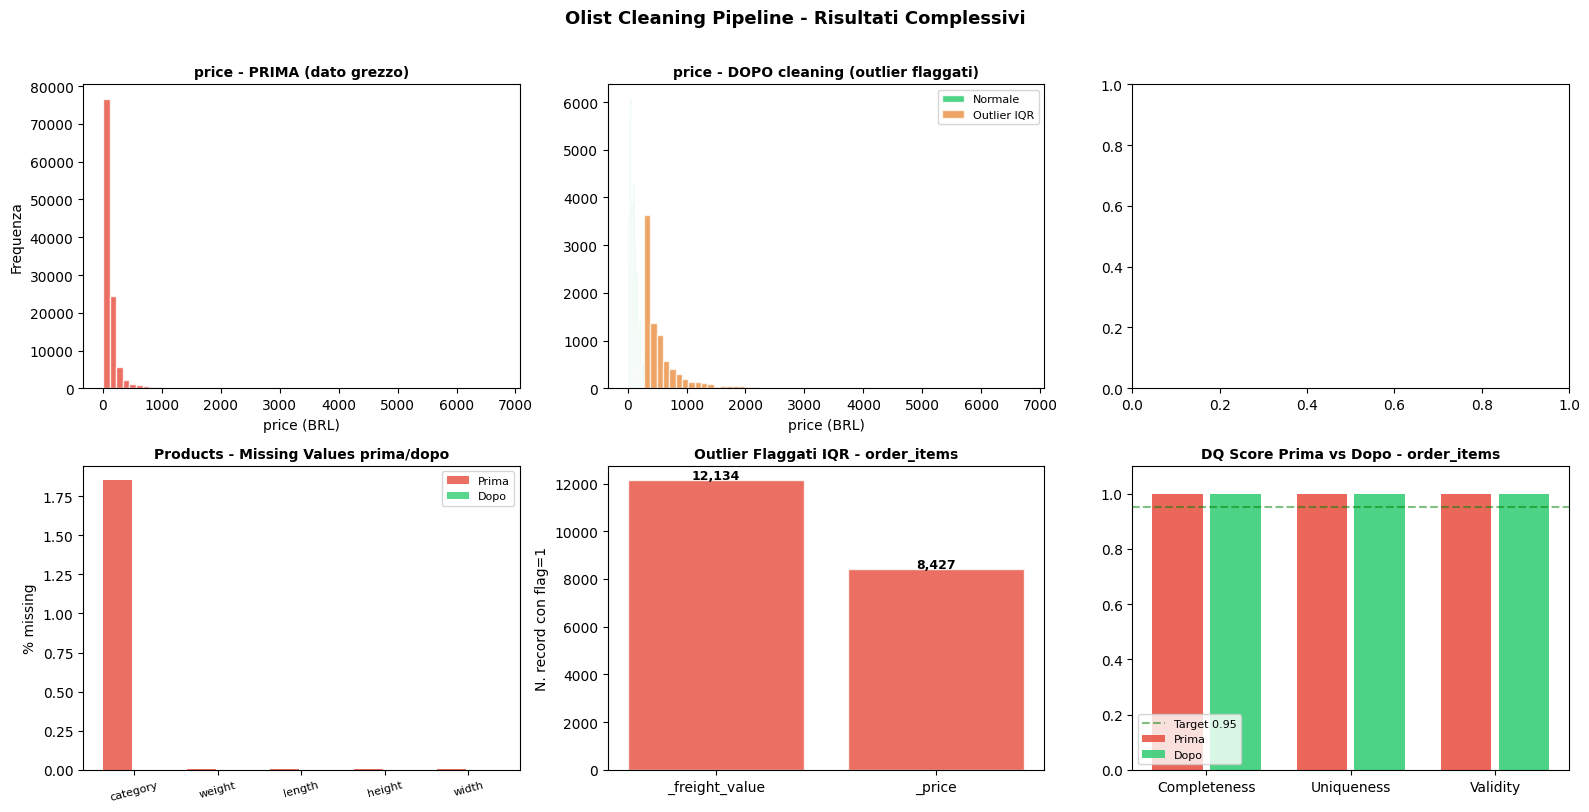

Grafico salvato: cleaning_pipeline_results.png


In [28]:
# Visualizzazione 2x3 stile lezione: prima/dopo cleaning
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# (0,0) price PRIMA
ax = axes[0, 0]
_oi_raw = pd.read_csv(INPUT_PATH + 'olist_order_items_dataset.csv')
ax.hist(_oi_raw['price'].dropna(), bins=60, color='#e74c3c', alpha=0.8, edgecolor='white')
ax.set_title('price - PRIMA (dato grezzo)', fontweight='bold', fontsize=10)
ax.set_xlabel('price (BRL)')
ax.set_ylabel('Frequenza')

# (0,1) price DOPO con outlier evidenziati
ax = axes[0, 1]
nm = order_items['_price_outlier'] == 0
om = order_items['_price_outlier'] == 1
ax.hist(order_items.loc[nm, 'price'].dropna(), bins=60, color='#2ecc71', alpha=0.85, edgecolor='white', label='Normale')
ax.hist(order_items.loc[om, 'price'].dropna(), bins=60, color='#e67e22', alpha=0.7, edgecolor='white', label='Outlier IQR')
ax.set_title('price - DOPO cleaning (outlier flaggati)', fontweight='bold', fontsize=10)
ax.set_xlabel('price (BRL)')
ax.legend(fontsize=8)

# (0,2) Audit log
ax = axes[0, 2]
adf = pd.DataFrame(audit_log)
if 'step' in adf.columns and 'changes' in adf.columns:
    adf.groupby('step')['changes'].sum().sort_values().plot(kind='barh', ax=ax, color='#3498db', alpha=0.85)
    ax.set_title('Audit Log: Modifiche per Step', fontweight='bold', fontsize=10)
    ax.set_xlabel('N. modifiche')

# (1,0) Missing values products prima/dopo
ax = axes[1, 0]
_pr = pd.read_csv(INPUT_PATH + 'olist_products_dataset.csv')
mc = ['product_category_name','product_weight_g','product_length_cm','product_height_cm','product_width_cm']
mb = (_pr[mc].isnull().sum() / len(_pr) * 100)
ma = (products[[c for c in mc if c in products.columns]].isnull().sum() / len(products) * 100)
xp = np.arange(len(mc))
ax.bar(xp-0.2, mb.values, 0.35, label='Prima', color='#e74c3c', alpha=0.8)
ax.bar(xp+0.2, ma.reindex(mc, fill_value=0).values, 0.35, label='Dopo', color='#2ecc71', alpha=0.8)
ax.set_xticks(xp)
ax.set_xticklabels(['category','weight','length','height','width'], rotation=15, fontsize=8)
ax.set_ylabel('% missing')
ax.set_title('Products - Missing Values prima/dopo', fontweight='bold', fontsize=10)
ax.legend(fontsize=8)

# (1,1) Outlier flaggati per colonna
ax = axes[1, 1]
fc = [c for c in order_items.columns if c.endswith('_outlier')]
fv = order_items[fc].sum().sort_values(ascending=False)
fl = [c.replace('_outlier','') for c in fv.index]
ax.bar(fl, fv.values, color='#e74c3c', alpha=0.8, edgecolor='white')
for i,v in enumerate(fv.values):
    ax.text(i, v+50, f'{v:,}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Outlier Flaggati IQR - order_items', fontweight='bold', fontsize=10)
ax.set_ylabel('N. record con flag=1')

# (1,2) DQ Score prima/dopo
ax = axes[1, 2]
sc = [c for c in _oi_raw.columns if c in order_items.columns]
dims = ['Completeness','Uniqueness','Validity']
bs = [round(1-_oi_raw.isnull().mean().mean(),4),
      round(1-_oi_raw.duplicated().mean(),4),
      round((_oi_raw['price']>0).mean(),4)]
as_ = [round(1-order_items[sc].isnull().mean().mean(),4),
       round(1-order_items.duplicated().mean(),4),
       round((order_items['price']>0).mean(),4)]
xd = np.arange(len(dims))
ax.bar(xd-0.2, bs, 0.35, label='Prima', color='#e74c3c', alpha=0.85)
ax.bar(xd+0.2, as_, 0.35, label='Dopo', color='#2ecc71', alpha=0.85)
ax.set_xticks(xd)
ax.set_xticklabels(dims)
ax.set_ylim(0, 1.1)
ax.axhline(0.95, color='green', linestyle='--', alpha=0.5, label='Target 0.95')
ax.set_title('DQ Score Prima vs Dopo - order_items', fontweight='bold', fontsize=10)
ax.legend(fontsize=8)

plt.suptitle('Olist Cleaning Pipeline - Risultati Complessivi', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'cleaning_pipeline_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico salvato: cleaning_pipeline_results.png')


## 7. Export - Salvataggio dataset puliti


In [ ]:
import os
os.makedirs(OUTPUT_PATH, exist_ok=True)

datasets = {
    'dim_customers.csv':    customers,
    'dim_sellers.csv':      sellers,
    'dim_products.csv':     products,
    'dim_geolocation.csv':  geolocation,
    'fact_orders.csv':      orders,
    'fact_order_items.csv': order_items,
    'fact_payments.csv':    payments,
    'fact_reviews.csv':     reviews,
}

for fname, df in datasets.items():
    df.to_csv(OUTPUT_PATH + fname, index=False)
    print(f'Salvato: {fname} ({df.shape[0]:,} righe, {df.shape[1]} col)')

# Salva anche audit log
audit_df = pd.DataFrame(audit_log)
audit_df.to_csv(OUTPUT_PATH + 'audit_log.csv', index=False)
print(f'Salvato: audit_log.csv ({len(audit_df)} operazioni)')
print('\nExport completato. 8 CSV + audit_log nella cartella cleaned/')

Salvato: customers_clean.csv (99,441 righe, 5 col)
Salvato: orders_clean.csv (99,441 righe, 11 col)
Salvato: order_items_clean.csv (112,650 righe, 9 col)
Salvato: products_clean.csv (32,951 righe, 17 col)
Salvato: sellers_clean.csv (3,095 righe, 4 col)
Salvato: reviews_clean.csv (98,410 righe, 7 col)
Salvato: payments_clean.csv (103,886 righe, 5 col)
Export completato.


## 8. Audit Log - Riepilogo operazioni


In [42]:
audit_df = pd.DataFrame(audit_log)
print('=== AUDIT LOG - Pipeline Olist DW ===')
print(audit_df.to_string(index=False))
print(f'\nTotale operazioni: {len(audit_df)}')


=== AUDIT LOG - Pipeline Olist DW ===
          timestamp       table             step  rows_before  cols_before  rows_after  cols_after  rows_changed                                                                                               notes
2026-05-05 08:44:24   customers    deduplication        99441            5       99441           5             0                                                             PK=['customer_id'], rimossi 0 duplicati
2026-05-05 08:44:24     sellers    deduplication         3095            4        3095           4             0                                                               PK=['seller_id'], rimossi 0 duplicati
2026-05-05 08:44:24    products    deduplication        32951            9       32951           9             0                                                              PK=['product_id'], rimossi 0 duplicati
2026-05-05 08:44:24      orders    deduplication        99441            8       99441           8            

## Pipeline completata

1. **Caricamento** - lettura CSV con dtype espliciti
2. **Deduplicazione** - `drop_duplicates()`
3. **Standardizzazione** - `str.upper()`, `str.title()`, `str.strip()`
4. **Parsing date** - `pd.to_datetime()`
5. **Imputazione** - `unknown` per categoriali, mediana per numerici
6. **Outlier IQR** - flag `_outlier`, valori originali preservati
7. **Export** - dataset puliti salvati in CSV
